In [1]:
# importing all the libraries i need
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input

from skimage.metrics import structural_similarity

np.random.seed(42)
tf.random.set_seed(42)

# setting up plot style same as previous experiments
# 600 dpi, Times New Roman font, save as .eps
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600


def save_plot(filename):
    plt.savefig(f"{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    print(f"saved {filename}.eps")


In [2]:
(x_train_all, y_train_all), (x_test_all, y_test_all) = tf.keras.datasets.mnist.load_data()

N_TRAIN, N_TEST, N_VAL = 10000, 2000, 1000   # recommended lab subset sizes

# taking a RANDOM subset of the recommended size (not just the first N images)
# so the subset isn't affected by the order images appear in the original files
train_idx = np.random.permutation(len(x_train_all))[:N_TRAIN]
test_idx = np.random.permutation(len(x_test_all))[:N_TEST]

# pixel values [0,255] -> [0,1]
x_train = x_train_all[train_idx].astype('float32') / 255.0
x_test = x_test_all[test_idx].astype('float32') / 255.0
y_train = y_train_all[train_idx]
y_test = y_test_all[test_idx]

# the labels are NOT used as training targets anywhere - the image is its own
# target (x -> Encoder -> z -> Decoder -> x_hat). labels are only used at the
# end to colour the VAE latent space plot.

x_train_img = x_train[..., np.newaxis]           # (10000, 28, 28, 1) for conv models
x_test_img = x_test[..., np.newaxis]             # (2000, 28, 28, 1)
x_train_flat = x_train.reshape(len(x_train), -1)  # (10000, 784) for the FC model
x_test_flat = x_test.reshape(len(x_test), -1)     # (2000, 784)

# out of the 10000 recommended training images, 9000 are used to update the
# weights and 1000 are held out as validation - every model in this experiment
# uses exactly this same split so results stay directly comparable
x_tr_img, x_val_img = x_train_img[:-N_VAL], x_train_img[-N_VAL:]
x_tr_flat, x_val_flat = x_train_flat[:-N_VAL], x_train_flat[-N_VAL:]

11490434/11490434 [==============================] - 3s 0us/step


In [3]:
# required preprocessing output (Section 4)
print("Training pool :", x_train_img.shape, " (train:", x_tr_img.shape,
      " val:", x_val_img.shape, ")")
print("Test set      :", x_test_img.shape)
print("FC input size : 28*28 =", 28 * 28)
print("A batch of 32 images has shape", (32, 28, 28, 1),
      "or", (32, 784), "when flattened")
print("Pixel value range after normalization: [0, 1]")
print("Expected output per image: 28x28x1 reconstruction")
print("Digit distribution in test subset:",
      dict(zip(*np.unique(y_test, return_counts=True))))



Training pool : (10000, 28, 28, 1)  (train: (9000, 28, 28, 1)  val: (1000, 28, 28, 1) )
Test set      : (2000, 28, 28, 1)
FC input size : 28*28 = 784
A batch of 32 images has shape (32, 28, 28, 1) or (32, 784) when flattened
Pixel value range after normalization: [0, 1]
Expected output per image: 28x28x1 reconstruction
Digit distribution in test subset: {0: 200, 1: 233, 2: 199, 3: 201, 4: 176, 5: 174, 6: 200, 7: 201, 8: 215, 9: 201}


In [4]:
# small shared helpers used throughout the experiment

def reconstruction_metrics(clean, recon):
    """Section 9: test MSE, MAE and mean SSIM between clean originals and
    reconstructions. Arrays may be (N,28,28), (N,28,28,1) or (N,784)."""
    clean = clean.reshape(len(clean), 28, 28)
    recon = recon.reshape(len(recon), 28, 28)
    mse = float(np.mean((clean - recon) ** 2))
    mae = float(np.mean(np.abs(clean - recon)))
    ssim_scores = [structural_similarity(clean[i], recon[i], data_range=1.0)
                   for i in range(len(clean))]
    return mse, mae, float(np.mean(ssim_scores))


def fit_and_time(model, x_tr, y_tr, x_val, y_val, name, epochs=20, batch_size=128):
    """Trains one model, times it and prints the final train/val losses.
    Works for the plain AEs (history key 'loss') and the VAE (custom key
    'total_loss'), so the same helper covers every model here."""
    start = time.time()
    history = model.fit(x_tr, y_tr, validation_data=(x_val, y_val),
                        epochs=epochs, batch_size=batch_size, verbose=0)
    elapsed = time.time() - start
    h = history.history
    key = 'loss' if 'loss' in h else 'total_loss'
    print(f"[{name}] final train loss={h[key][-1]:.4f}  "
          f"val loss={h['val_' + key][-1]:.4f}  time={elapsed:.1f}s")
    return history, elapsed


def display_image_columns(columns, n, title, filename, error_list=None):
    """Shows n rows of images side by side, one column per (name, images) pair,
    e.g. columns=[('Original', x), ('Reconstruction', r)]. If error_list is
    given, each image of the LAST column also shows its per-image MSE."""
    ncols = len(columns)
    plt.figure(figsize=(1.6 * ncols, 1.7 * n))
    for row in range(n):
        for col, (col_name, images) in enumerate(columns):
            plt.subplot(n, ncols, row * ncols + col + 1)
            plt.imshow(images[row].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
            plt.axis('off')
            if row == 0:
                if error_list is not None and col == ncols - 1:
                    plt.title(f"{col_name}\nMSE={error_list[0]:.4f}", fontsize=8)
                else:
                    plt.title(col_name, fontsize=10)
            elif error_list is not None and col == ncols - 1:
                plt.title(f"MSE={error_list[row]:.4f}", fontsize=7)
    plt.suptitle(title)
    plt.tight_layout()
    save_plot(filename)
    plt.show()


def show_image_grid(images, cols, title, filename, titles=None):
    """Displays a list of 28x28 images in a grid with `cols` columns."""
    n = len(images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(1.4 * cols, 1.4 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
        if titles is not None:
            plt.title(titles[i], fontsize=7)
    plt.suptitle(title)
    plt.tight_layout()
    save_plot(filename)
    plt.show()


In [5]:
# training objective: minimize reconstruction error L_rec = (1/N) sum ||x - x_hat||^2,
# implemented as binary cross-entropy per the manual's suggested configuration
# (Adam lr=1e-3, batch 128, 20 epochs, latent dim 16)
def build_fc_ae(latent_dim=16):
    """Section 7 architecture: 784 - 128 - 32 - (latent) - 32 - 128 - 784."""
    model = models.Sequential([
        Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(latent_dim, activation='relu'),   # latent vector z (bottleneck)
        layers.Dense(32, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(784, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy')
    return model


fc_ae = build_fc_ae(16)
fc_ae.summary()
fc_history, fc_time = fit_and_time(fc_ae, x_tr_flat, x_tr_flat,
                                    x_val_flat, x_val_flat, "FC-AE (dz=16)")


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 32)                4128      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 32)                544       
                                                                 
 dense_4 (Dense)             (None, 128)               4224      
                                                                 
 dense_5 (Dense)             (None, 784)               101136    
                                                                 
Total params: 211040 (824.38 KB)
Trainable params: 2110

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fc_ae_loss_curve.eps


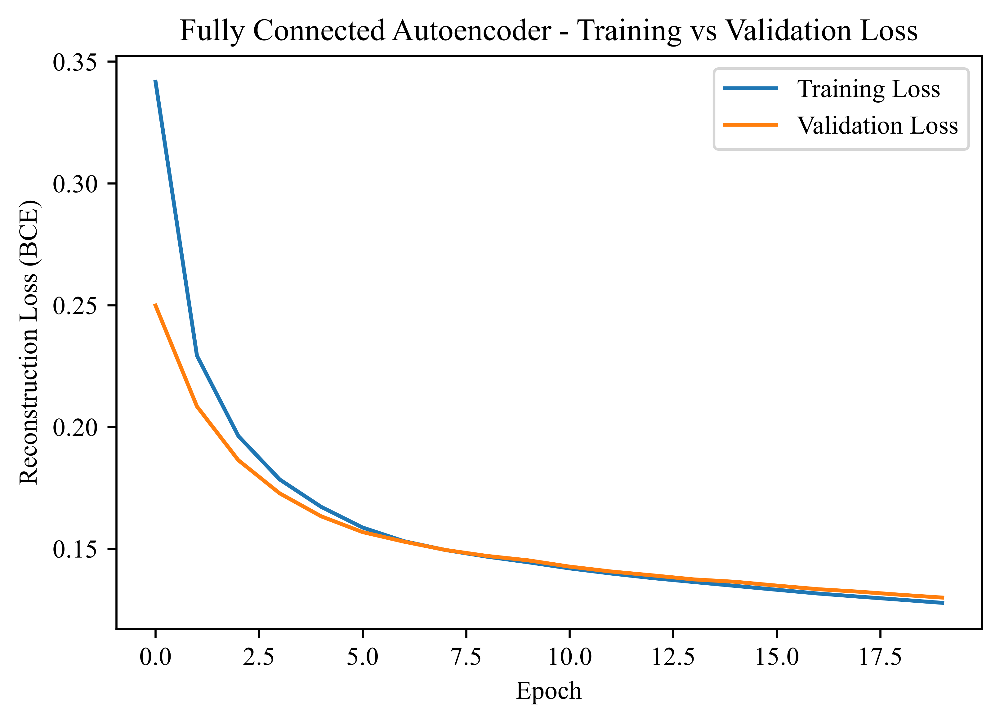

In [6]:
# Plot 2 - training and validation reconstruction loss
plt.figure(figsize=(6, 4))
plt.plot(fc_history.history['loss'], label='Training Loss')
plt.plot(fc_history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch"); plt.ylabel("Reconstruction Loss (BCE)")
plt.title("Fully Connected Autoencoder - Training vs Validation Loss")
plt.legend()
save_plot("fc_ae_loss_curve")
plt.show()

# Inference: both curves fall steeply and then flatten, so the model converges.
# The validation loss stays close to the training loss throughout, so there is
# no real evidence of overfitting - a growing train-val gap would indicate it.

saved fc_ae_reconstruction.eps




In [7]:
# Plot 1 - original versus reconstructed test images (with per-image MSE)
fc_recon = fc_ae.predict(x_test_flat, verbose=0).reshape(-1, 28, 28)
per_image_mse_fc = np.mean((x_test - fc_recon) ** 2, axis=(1, 2))

display_image_columns(
    [("Original", x_test), ("Reconstruction", fc_recon)],
    n=10,
    title="Original vs Reconstructed Test Images (FC Autoencoder, dz=16)",
    filename="fc_ae_reconstruction",
    error_list=per_image_mse_fc[:10]
)

# Inference (required points from Section 8):
# 1. digit shape is preserved - every reconstruction is still recognisable as
#    the same digit, so the 16-dim latent code carries the class structure
# 2. fine details are lost - thin strokes come back thicker/blurrier because
#    the bottleneck cannot store every pixel-level detail
# 3. blurred regions appear where strokes are close together (inside 8s, 9s,
#    3s) - the model averages nearby strokes together
# 4. easy samples (clean 0s and 1s) reconstruct almost perfectly while
#    difficult samples (slanted or unusual handwriting) get visibly higher
#    error, which matches the per-image MSE titles above

In [8]:
fc_mse, fc_mae, fc_ssim = reconstruction_metrics(x_test, fc_recon)

fc_metrics_table = pd.DataFrame({
    "Metric": ["Test MSE", "Test MAE", "Mean SSIM"],
    "Value": [fc_mse, fc_mae, fc_ssim],
})
print(fc_metrics_table.to_string(index=False))

# Inference: MSE/MAE look small because most pixels are easy (background);
# SSIM staying high shows the overall structure is preserved. The error is
# concentrated on the stroke pixels, exactly what Plot 1 shows visually.



   Metric    Value
 Test MSE 0.021484
 Test MAE 0.057818
Mean SSIM 0.754313


In [9]:
def build_conv_ae(latent_dim=None, transposed_decoder=False):
    """Section 10 architecture. With latent_dim=None the latent space is the
    natural 7x7x64 feature map; otherwise a Dense bottleneck compresses it to
    exactly latent_dim (used in the latent-dimension studies). Setting
    transposed_decoder=True swaps UpSampling+Conv for Conv2DTranspose."""
    # ---- encoder ----
    enc_in = Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(enc_in)
    x = layers.MaxPooling2D(2, padding='same')(x)      # 14x14x32
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)      # 7x7x64 latent feature map
    if latent_dim is not None:
        x = layers.Flatten()(x)
        latent = layers.Dense(latent_dim, activation='relu')(x)
    else:
        latent = x
    encoder = Model(enc_in, latent, name='encoder')

    # ---- decoder ----
    if latent_dim is not None:
        dec_in = Input(shape=(latent_dim,))
        y = layers.Dense(7 * 7 * 64, activation='relu')(dec_in)
        y = layers.Reshape((7, 7, 64))(y)
    else:
        dec_in = Input(shape=(7, 7, 64))
        y = dec_in
    if transposed_decoder:
        y = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(y)  # 14x14
        y = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(y)  # 28x28
    else:
        y = layers.Conv2D(64, 3, activation='relu', padding='same')(y)
        y = layers.UpSampling2D(2)(y)                  # 14x14
        y = layers.Conv2D(32, 3, activation='relu', padding='same')(y)
        y = layers.UpSampling2D(2)(y)                  # 28x28
    dec_out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(y)
    decoder = Model(dec_in, dec_out, name='decoder')

    autoencoder = Model(enc_in, decoder(encoder(enc_in)), name='conv_ae')
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                        loss='binary_crossentropy')
    return autoencoder, encoder, decoder


cae, cae_encoder, cae_decoder = build_conv_ae()
cae.summary()
cae_history, cae_time = fit_and_time(cae, x_tr_img, x_tr_img,
                                      x_val_img, x_val_img, "Conv-AE")



Model: "conv_ae"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 encoder (Functional)        (None, 7, 7, 64)          18816     
                                                                 
 decoder (Functional)        (None, 28, 28, 1)         55681     
                                                                 
Total params: 74497 (291.00 KB)
Trainable params: 74497 (291.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
[Conv-AE] final train loss=0.0690  val loss=0.0696  time=56.4s


saved cae_latent_feature_maps.eps


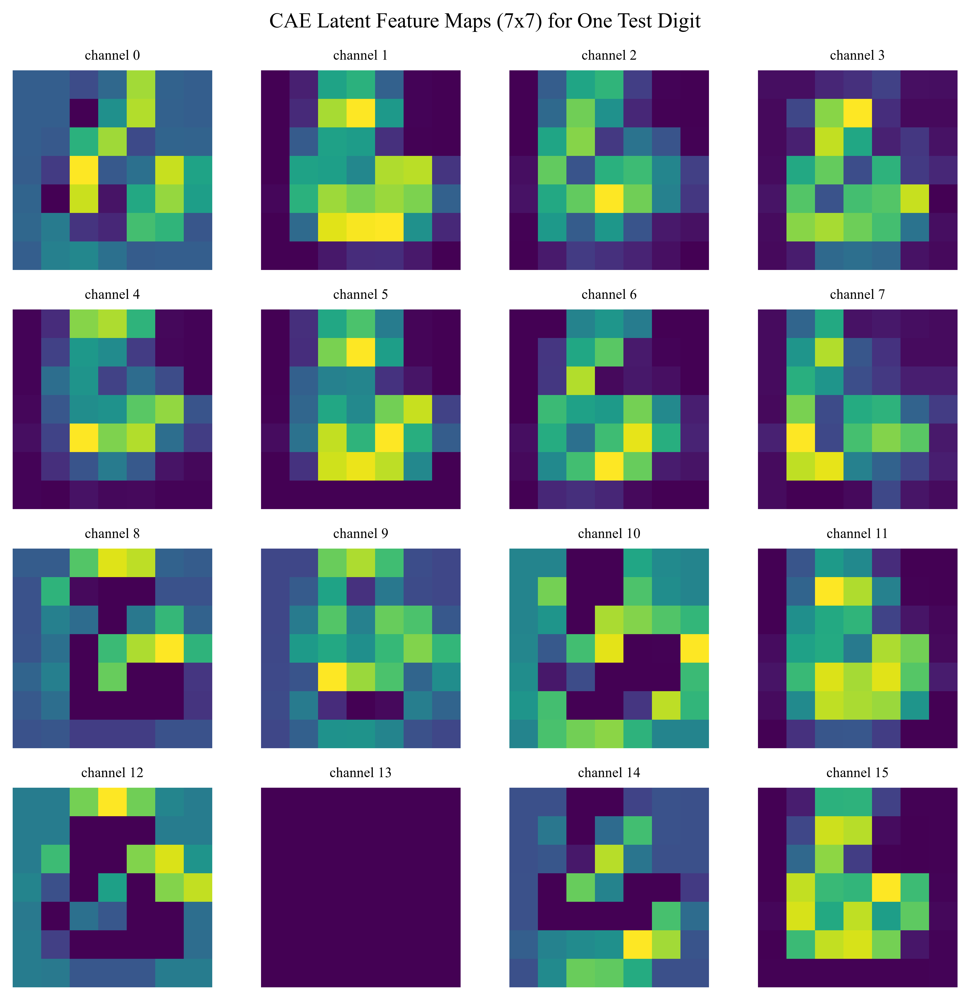

In [10]:
# peeking at the learned latent representation: first 16 channels of the
# 7x7x64 latent feature map for one test digit
latent_maps = cae_encoder.predict(x_test_img[:1], verbose=0)   # (1, 7, 7, 64)
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(latent_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f"channel {i}", fontsize=8)
plt.suptitle("CAE Latent Feature Maps (7x7) for One Test Digit")
plt.tight_layout()
save_plot("cae_latent_feature_maps")
plt.show()

# Inference: the latent keeps a 7x7 spatial layout, so each activation still
# corresponds to a region of the image - different channels light up for
# different stroke parts. This spatial arrangement is exactly what a flattened
# dense latent throws away.


             Model      MSE      MAE     SSIM  Parameters
Fully Connected AE 0.021484 0.057818 0.754313      211040
  Convolutional AE 0.002682 0.015649 0.972809       74497
saved fc_vs_conv_reconstruction.eps


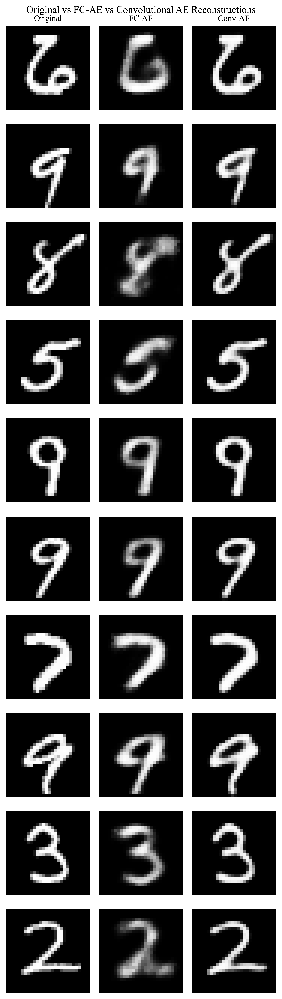

In [11]:
# Plot 3 - original vs FC-AE vs CAE + the Section 11 comparison table
cae_recon = cae.predict(x_test_img, verbose=0)
cae_mse, cae_mae, cae_ssim = reconstruction_metrics(x_test, cae_recon)

comparison_table = pd.DataFrame({
    "Model": ["Fully Connected AE", "Convolutional AE"],
    "MSE": [fc_mse, cae_mse],
    "MAE": [fc_mae, cae_mae],
    "SSIM": [fc_ssim, cae_ssim],
    "Parameters": [fc_ae.count_params(), cae.count_params()],
})
print(comparison_table.to_string(index=False))

display_image_columns(
    [("Original", x_test), ("FC-AE", fc_recon), ("Conv-AE", cae_recon)],
    n=10,
    title="Original vs FC-AE vs Convolutional AE Reconstructions",
    filename="fc_vs_conv_reconstruction"
)

# Inference: the CAE reconstructs more sharply even though it has FEWER
# parameters than the FC model. Two reasons:
# (a) convolutions exploit spatial locality - nearby pixels are related, so
#     sharing filters across all image locations is very efficient
# (b) its latent is a 7x7x64 feature map (3136 values vs only 16 for the FC
#     model), so it also simply keeps more information past the bottleneck
# Together these explain the lower MSE and higher SSIM in the table.


In [12]:
# Section 13 corruption functions (two types, as required)
def add_gaussian_noise(x, sigma):
    """Gaussian noise: x_tilde = x + n, n ~ N(0, sigma^2), clipped to [0,1]."""
    noisy = x + np.random.normal(0.0, sigma, size=x.shape)
    return np.clip(noisy, 0.0, 1.0).astype('float32')


def add_salt_pepper_noise(x, p):
    """Salt-and-pepper: replaces about p of the pixels with 0 (pepper) or 1 (salt)."""
    noisy = x.copy()
    r = np.random.random(size=x.shape)
    noisy[r < p / 2] = 0.0
    noisy[r >= 1 - p / 2] = 1.0
    return noisy.astype('float32')


# training mapping is  x_tilde -> Encoder -> z -> Decoder -> x_hat
# the INPUT is corrupted, the TARGET stays the clean original
SIGMA_TRAIN = 0.2   # middle of the suggested range {0.1, 0.2, 0.3}
x_tr_noisy = add_gaussian_noise(x_tr_img, SIGMA_TRAIN)
x_val_noisy = add_gaussian_noise(x_val_img, SIGMA_TRAIN)

# NOTE: the noisy training images are generated once, so every epoch sees the
# same noisy copies (re-sampling fresh noise each epoch is a possible
# extension, but this keeps the protocol simple and controlled)

dae, _, _ = build_conv_ae()   # same CAE architecture, new weights
dae_history, dae_time = fit_and_time(dae, x_tr_noisy, x_tr_img,
                                      x_val_noisy, x_val_img, "Denoising-CAE")


[Denoising-CAE] final train loss=0.0760  val loss=0.0767  time=55.0s


saved denoise_gaussian_comparison.eps


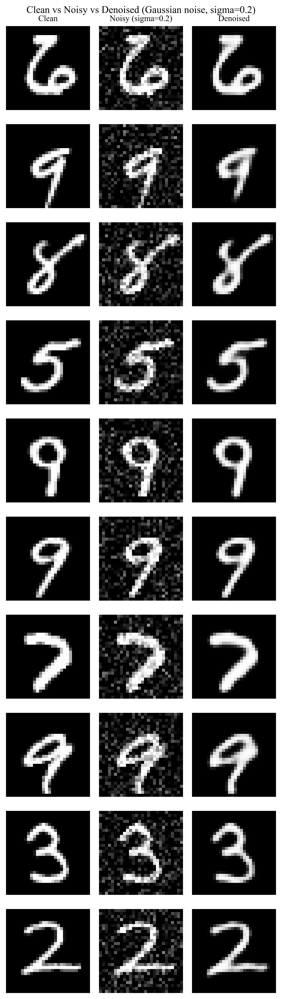

In [13]:
# Plot 4 - clean vs noisy vs denoised
x_test_noisy_02 = add_gaussian_noise(x_test_img, 0.2)
dae_out_02 = dae.predict(x_test_noisy_02, verbose=0)

display_image_columns(
    [("Clean", x_test), ("Noisy (sigma=0.2)", x_test_noisy_02), ("Denoised", dae_out_02)],
    n=10,
    title="Clean vs Noisy vs Denoised (Gaussian noise, sigma=0.2)",
    filename="denoise_gaussian_comparison"
)

# Inference: the denoising CAE recovers the major structure of the digits -
# strokes that were almost buried under the noise come back as recognisable
# shapes, though the fine detail stays slightly smoother than the original.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Gaussian noise level study (the manual's required table is the 'Denoised' columns):
 Sigma  Denoised MSE  Denoised MAE  Denoised SSIM  Noisy MSE  Noisy MAE  Noisy SSIM
   0.1      0.003636      0.018023       0.960311   0.005436   0.044135    0.697605
   0.2      0.004655      0.021622       0.946269   0.021279   0.086842    0.612951
   0.3      0.007038      0.029122       0.887798   0.046736   0.128193    0.528391
saved noise_level_vs_metrics.eps


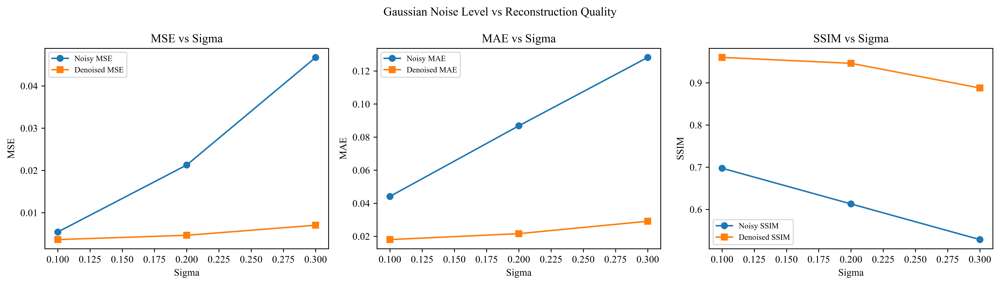

In [14]:
# Plot 5 - noise level vs reconstruction quality (Gaussian)
def noise_sweep(model, noise_fn, levels, level_name):
    """Applies each corruption level to the test set, denoises it with the
    trained model, and compares both the noisy and denoised images against
    the clean originals."""
    rows = []
    for level in levels:
        x_noisy = noise_fn(x_test_img, level)
        x_denoised = model.predict(x_noisy, verbose=0)
        d_mse, d_mae, d_ssim = reconstruction_metrics(x_test_img, x_denoised)
        n_mse, n_mae, n_ssim = reconstruction_metrics(x_test_img, x_noisy)
        rows.append({level_name: level,
                     "Denoised MSE": d_mse, "Denoised MAE": d_mae, "Denoised SSIM": d_ssim,
                     "Noisy MSE": n_mse, "Noisy MAE": n_mae, "Noisy SSIM": n_ssim})
    return pd.DataFrame(rows)


def plot_noise_sweep(table, level_name, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, ["MSE", "MAE", "SSIM"]):
        ax.plot(table[level_name], table[f"Noisy {metric}"], marker='o', label=f"Noisy {metric}")
        ax.plot(table[level_name], table[f"Denoised {metric}"], marker='s', label=f"Denoised {metric}")
        ax.set_xlabel(level_name)
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs {level_name}")
        ax.legend(fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    save_plot(filename)
    plt.show()


gauss_table = noise_sweep(dae, add_gaussian_noise, [0.1, 0.2, 0.3], "Sigma")
print("Gaussian noise level study (the manual's required table is the "
      "'Denoised' columns):")
print(gauss_table.to_string(index=False))
plot_noise_sweep(gauss_table, "Sigma",
                 "Gaussian Noise Level vs Reconstruction Quality",
                 "noise_level_vs_metrics")

# Inference: as sigma increases the corrupted input gets worse (rising 'Noisy'
# curves) and the denoised error also rises, but it stays far below the noisy
# error at every level - the model learned to map corrupted images back toward
# the clean data manifold instead of copying the noise. Degradation is gradual
# rather than sudden; beyond the training level (0.2) quality drops a little
# faster because the corruption is increasingly out of distribution.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Salt-and-pepper noise level study (same Gaussian-trained denoiser):
   p  Denoised MSE  Denoised MAE  Denoised SSIM  Noisy MSE  Noisy MAE  Noisy SSIM
0.05      0.004933      0.021204       0.938076   0.023945   0.024870    0.724014
0.10      0.007138      0.026795       0.900202   0.048469   0.050322    0.594677
0.20      0.013216      0.040365       0.802060   0.096541   0.100267    0.463694
saved salt_pepper_noise_level_vs_metrics.eps


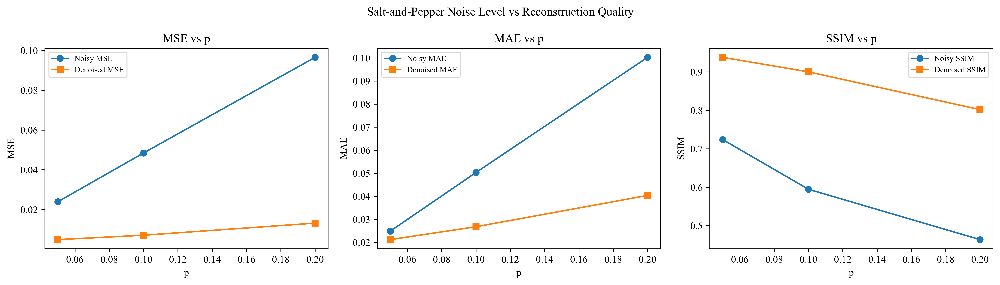

In [18]:
# same denoiser evaluated on the second required corruption type (S&P)
sp_table = noise_sweep(dae, add_salt_pepper_noise, [0.05, 0.10, 0.20], "p")
print("Salt-and-pepper noise level study (same Gaussian-trained denoiser):")
print(sp_table.to_string(index=False))
plot_noise_sweep(sp_table, "p",
                 "Salt-and-Pepper Noise Level vs Reconstruction Quality",
                 "salt_pepper_noise_level_vs_metrics")

# Inference: even though this denoiser was only trained on Gaussian noise it
# still removes most salt-and-pepper corruption at p=0.05/0.10, because
# isolated extreme pixels are easy to recognise as off-manifold; at p=0.20 too
# many pixels are destroyed at once and quality drops faster.


In [20]:
class VAE(tf.keras.Model):
    """VAE with encoder outputs (mu, log sigma^2), reparameterization-trick
    sampling, and the loss L_VAE = L_rec (BCE) + KL divergence.

    NOTE: the loss helper must NOT be named _losses - Keras Model/Layer
    already own an internal self._losses list (for add_loss()), and an
    instance attribute shadows a class method of the same name."""

    def __init__(self, encoder, decoder, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker,
                self.reconstruction_loss_tracker,
                self.kl_loss_tracker]

    def compute_vae_losses(self, data):
        """Samples z via the reparameterization trick, decodes it and
        returns (reconstruction_loss, kl_loss)."""
        z_mu, z_log_var = self.encoder(data)
        # reparameterization trick: z = mu + sigma * eps, with eps ~ N(0, I)
        eps = tf.random.normal(shape=tf.shape(z_mu))
        z = z_mu + tf.exp(0.5 * z_log_var) * eps
        reconstruction = self.decoder(z)
        # reconstruction loss: binary cross-entropy summed over all pixels
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction),
                          axis=(1, 2)))
        # KL divergence: -1/2 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mu) - tf.exp(z_log_var), axis=1))
        return reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, (tuple, list)):
            data = data[0]
        with tf.GradientTape() as tape:
            reconstruction_loss, kl_loss = self.compute_vae_losses(data)
            total_loss = reconstruction_loss + self.kl_weight * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, (tuple, list)):
            data = data[0]
        reconstruction_loss, kl_loss = self.compute_vae_losses(data)
        total_loss = reconstruction_loss + self.kl_weight * kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


def build_vae(latent_dim=2, kl_weight=1.0):
    """Sections 15-17: conv encoder -> (mu, log sigma^2) -> z -> dense +
    transposed-conv decoder. Latent dim 2 is used so the space can be plotted."""
    # ---- encoder ----
    enc_in = Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same', strides=2)(enc_in)   # 14x14x32
    x = layers.Conv2D(64, 3, activation='relu', padding='same', strides=2)(x)        # 7x7x64
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation='relu')(x)
    z_mu = layers.Dense(latent_dim, name="z_mu")(x)              # mu in R^d
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)    # log(sigma^2) in R^d
    encoder = Model(enc_in, [z_mu, z_log_var], name='vae_encoder')

    # ---- decoder ----
    dec_in = Input(shape=(latent_dim,))
    y = layers.Dense(7 * 7 * 64, activation='relu')(dec_in)
    y = layers.Reshape((7, 7, 64))(y)
    y = layers.Conv2DTranspose(64, 3, activation='relu', padding='same', strides=2)(y)  # 14x14
    y = layers.Conv2DTranspose(32, 3, activation='relu', padding='same', strides=2)(y)  # 28x28
    dec_out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(y)
    decoder = Model(dec_in, dec_out, name='vae_decoder')

    return VAE(encoder, decoder, kl_weight=kl_weight)


vae = build_vae(latent_dim=2)
vae.encoder.summary()
vae.decoder.summary()
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
vae_history, vae_time = fit_and_time(vae, x_tr_img, x_tr_img,
                                      x_val_img, x_val_img, "VAE (dz=2)", epochs=30)


Model: "vae_encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_8 (InputLayer)        [(None, 28, 28, 1)]          0         []                            
                                                                                                  
 conv2d_13 (Conv2D)          (None, 14, 14, 32)           320       ['input_8[0][0]']             
                                                                                                  
 conv2d_14 (Conv2D)          (None, 7, 7, 64)             18496     ['conv2d_13[0][0]']           
                                                                                                  
 flatten_1 (Flatten)         (None, 3136)                 0         ['conv2d_14[0][0]']           
                                                                                        

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved vae_loss_curves.eps


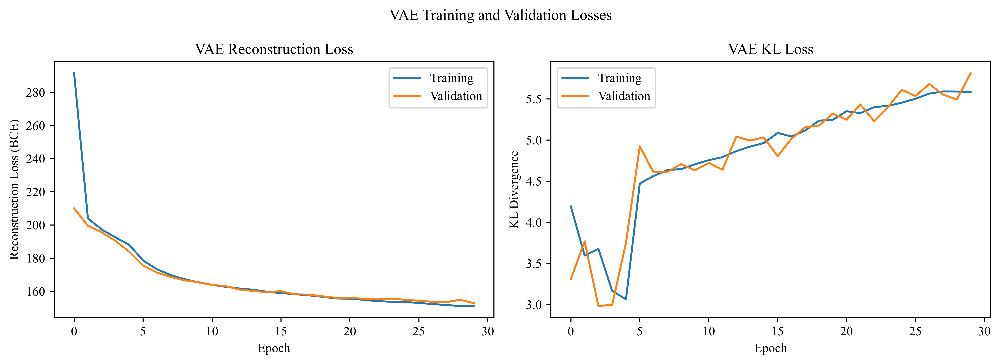

In [26]:
# Plot 9 (manual's required list) - training/validation losses for the VAE
vh = vae_history.history
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(vh['reconstruction_loss'], label='Training')
axes[0].plot(vh['val_reconstruction_loss'], label='Validation')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Reconstruction Loss (BCE)")
axes[0].set_title("VAE Reconstruction Loss"); axes[0].legend()
axes[1].plot(vh['kl_loss'], label='Training')
axes[1].plot(vh['val_kl_loss'], label='Validation')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("KL Divergence")
axes[1].set_title("VAE KL Loss"); axes[1].legend()
plt.suptitle("VAE Training and Validation Losses")
plt.tight_layout()
save_plot("vae_loss_curves")
plt.show()

# Inference: the reconstruction loss falls steadily then flattens, while the
# KL loss rises early (encoder variances get pushed toward the prior) and then
# stabilises. The two terms pull against each other - that is exactly the
# reconstruction-vs-regularisation trade-off the VAE has to balance.


saved vae_reconstruction.eps


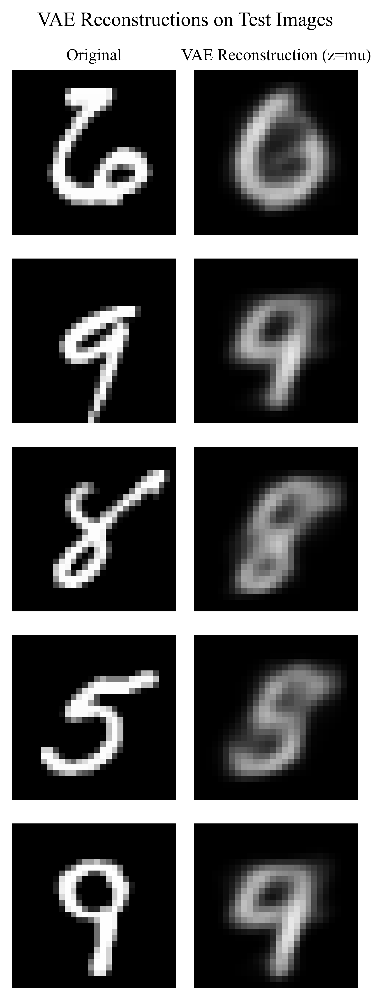

In [27]:
# VAE reconstructions on test images (using the deterministic z = mu)
z_mu_test, z_log_var_test = vae.encoder.predict(x_test_img, verbose=0)
vae_recon = vae.decoder.predict(z_mu_test, verbose=0)

display_image_columns(
    [("Original", x_test), ("VAE Reconstruction (z=mu)", vae_recon)],
    n=5,
    title="VAE Reconstructions on Test Images",
    filename="vae_reconstruction"
)

# Inference: VAE reconstructions are blurrier than the plain AEs because the
# decoder is trained on SAMPLED latents and the KL term restricts how much
# information each latent can carry - the price paid for a generative,
# well-organised latent space.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved vae_latent_space.eps


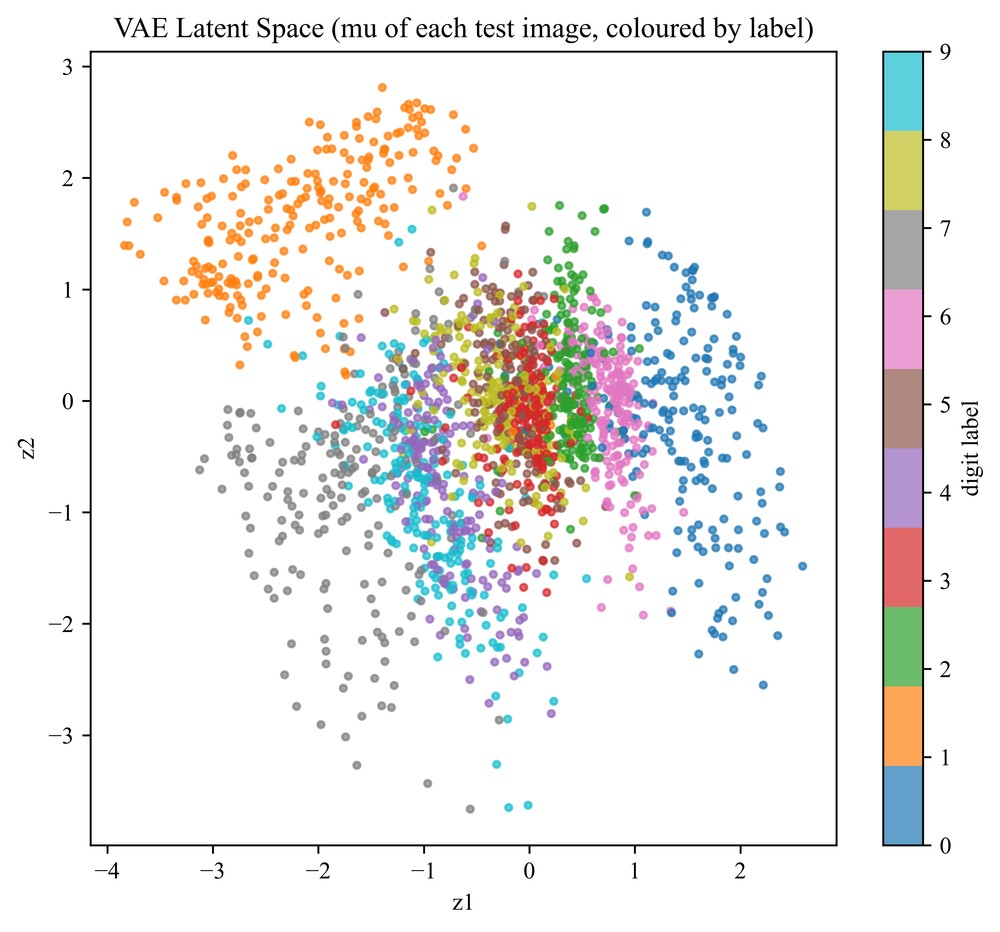

In [28]:
# Plot 6 - two-dimensional latent space, coloured by digit label
# (labels are used ONLY for this colouring, never during training)
plt.figure(figsize=(7, 6))
sc = plt.scatter(z_mu_test[:, 0], z_mu_test[:, 1], c=y_test, cmap='tab10', s=8, alpha=0.7)
plt.colorbar(sc, label="digit label")
plt.xlabel("z1"); plt.ylabel("z2")
plt.title("VAE Latent Space (mu of each test image, coloured by label)")
save_plot("vae_latent_space")
plt.show()

# Inference:
# - samples of the same digit occupy contiguous regions, so the 2D latent is
#   organised by digit identity even though labels were never used in training
# - neighbouring regions are visually similar digits (e.g. 3/8, 4/9, 7/1) and
#   their borders overlap - points decoded from the borders give the
#   ambiguous-looking samples
# - the whole cloud is centred near the origin and roughly Gaussian shaped -
#   the effect of the KL term pulling every q(z|x) toward N(0, I)

# Deterministic vs probabilistic latent (required inference):
# - a plain AE maps each image to one fixed point and the points sit
#   arbitrarily with gaps between them, so decoding a random point gives
#   garbage and sampling is meaningless
# - the VAE maps each image to a DISTRIBUTION and the KL term pulls all of
#   them toward N(0, I), filling the gaps so nearby latents decode to similar
#   images - this is what makes random sampling and smooth interpolation work

saved vae_generated_samples.eps


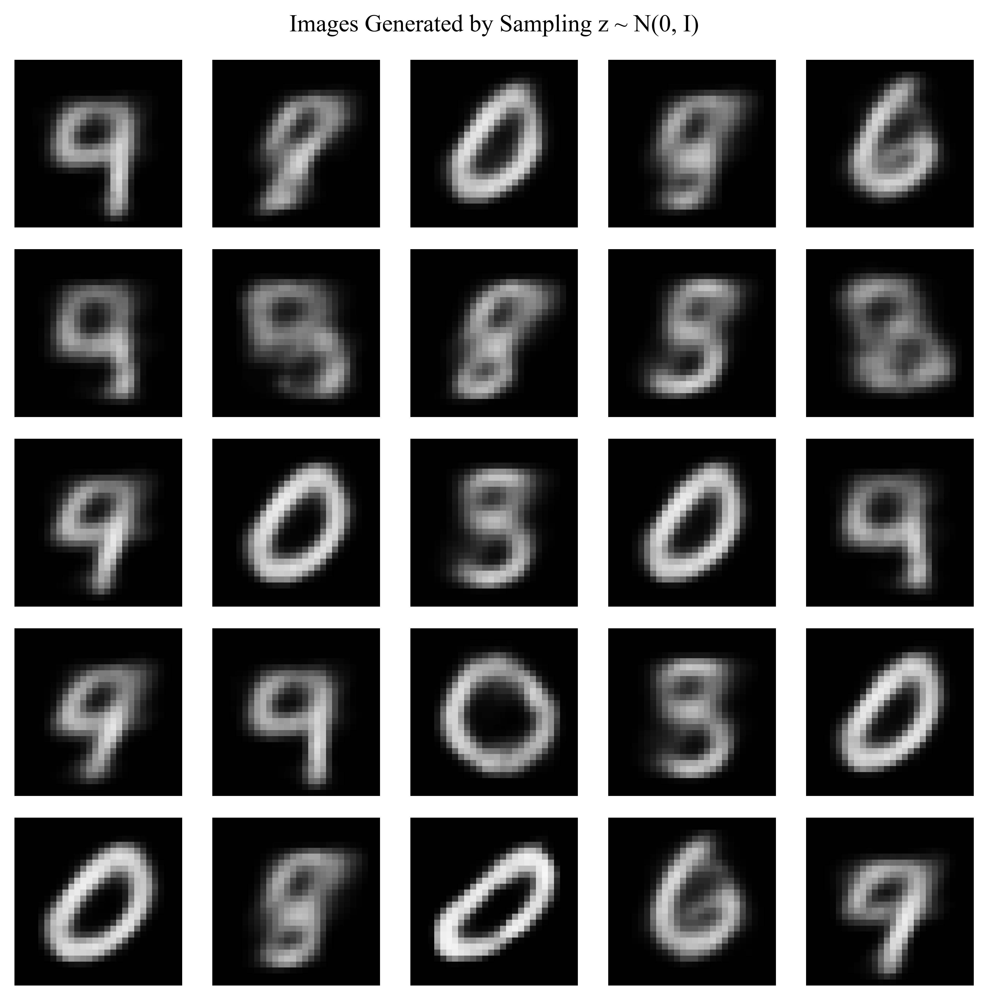

In [29]:
# Plot 7 - 25 images generated from z ~ N(0, I)
z_random = np.random.normal(0.0, 1.0, size=(25, 2))
generated = vae.decoder.predict(z_random, verbose=0)
show_image_grid(generated, cols=5,
                title="Images Generated by Sampling z ~ N(0, I)",
                filename="vae_generated_samples")

# Inference: most samples resemble handwritten digits with visible variation
# in slant, thickness and style, so the VAE is genuinely generating rather
# than memorising. A few are ambiguous or blobby - a 2D latent is a very tight
# bottleneck, and z drawn near cluster borders decodes to mixtures of digits.


saved vae_interpolation.eps


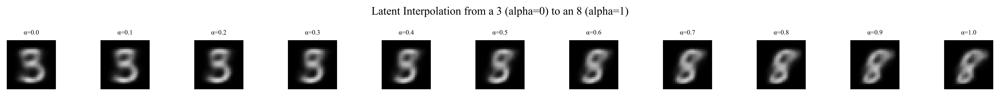

In [30]:
# Plot 8 - decode z(alpha) = (1-alpha)zA + alpha*zB for alpha = 0, 0.1, ..., 1
idx_a = int(np.where(y_test == 3)[0][0])
idx_b = int(np.where(y_test == 8)[0][0])

z_a, _ = vae.encoder.predict(x_test_img[idx_a:idx_a + 1], verbose=0)
z_b, _ = vae.encoder.predict(x_test_img[idx_b:idx_b + 1], verbose=0)

alphas = np.linspace(0, 1, 11)
z_interp = (1 - alphas)[:, None] * z_a + alphas[:, None] * z_b
interp_imgs = vae.decoder.predict(z_interp, verbose=0)

show_image_grid(interp_imgs, cols=11,
                title="Latent Interpolation from a 3 (alpha=0) to an 8 (alpha=1)",
                filename="vae_interpolation",
                titles=[f"α={a:.1f}" for a in alphas])

# Inference: the decoded image changes smoothly - the 3 gradually deforms into
# an 8 through plausible intermediate strokes with no sudden jump, so the
# latent space is continuous along this path. This smoothness is what the KL
# regularisation buys over a plain deterministic autoencoder.

In [31]:
# denoising CAE evaluated at its training noise level (sigma = 0.2 input)
dae_mse, dae_mae, dae_ssim = reconstruction_metrics(x_test, dae_out_02)

three_model_table = pd.DataFrame({
    "Model": ["Fully Connected AE", "Convolutional AE", "Denoising CAE (sigma=0.2 input)"],
    "MSE": [fc_mse, cae_mse, dae_mse],
    "MAE": [fc_mae, cae_mae, dae_mae],
    "SSIM": [fc_ssim, cae_ssim, dae_ssim],
    "Parameters": [fc_ae.count_params(), cae.count_params(), dae.count_params()],
})
print(three_model_table.to_string(index=False))

                          Model      MSE      MAE     SSIM  Parameters
             Fully Connected AE 0.021484 0.057818 0.754313      211040
               Convolutional AE 0.002682 0.015649 0.972809       74497
Denoising CAE (sigma=0.2 input) 0.004634 0.021571 0.946698       74497


In [32]:
# VAE losses on the test set, computed manually with the same formulas as
# train_step (z freshly sampled per image, exactly like during training)
eps_test = np.random.normal(size=z_mu_test.shape)
z_sampled = z_mu_test + np.exp(0.5 * z_log_var_test) * eps_test
recon_sampled = vae.decoder.predict(z_sampled, verbose=0)

bce_pixels = -(x_test_img * np.log(recon_sampled + 1e-7)
               + (1 - x_test_img) * np.log(1 - recon_sampled + 1e-7))
vae_rec_loss = float(np.sum(bce_pixels, axis=(1, 2, 3)).mean())
vae_kl_loss = float(np.mean(-0.5 * np.sum(1 + z_log_var_test - z_mu_test ** 2
                                           - np.exp(z_log_var_test), axis=1)))
vae_mse, vae_mae, vae_ssim = reconstruction_metrics(x_test, vae_recon)

vae_table = pd.DataFrame({
    "Metric": ["Reconstruction Loss (BCE)", "KL Loss", "Total Loss",
               "Test MSE", "Test MAE", "Mean SSIM"],
    "Value": [vae_rec_loss, vae_kl_loss, vae_rec_loss + vae_kl_loss,
              vae_mse, vae_mae, vae_ssim],
})
print(vae_table.to_string(index=False))

                   Metric      Value
Reconstruction Loss (BCE) 151.849945
                  KL Loss   5.820126
               Total Loss 157.670071
                 Test MSE   0.044264
                 Test MAE   0.102821
                Mean SSIM   0.502727


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved reconstruction_error_distribution.eps


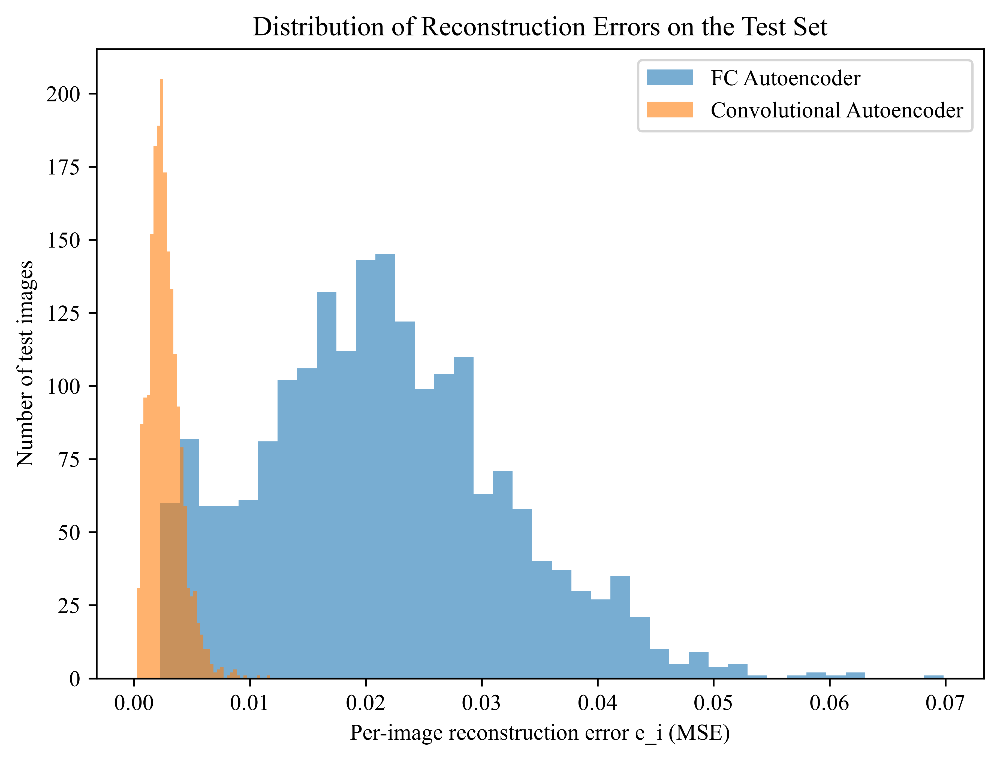

FC AE   error range: 0.0023 - 0.0698, median 0.0209
Conv AE error range: 0.0002 - 0.0117, median 0.0025


In [33]:
# Plot 10 (Section 23) - histogram of per-image reconstruction errors
per_image_mse_cae = np.mean((x_test - cae_recon.reshape(-1, 28, 28)) ** 2, axis=(1, 2))

plt.figure(figsize=(7, 5))
plt.hist(per_image_mse_fc, bins=40, alpha=0.6, label='FC Autoencoder')
plt.hist(per_image_mse_cae, bins=40, alpha=0.6, label='Convolutional Autoencoder')
plt.xlabel("Per-image reconstruction error e_i (MSE)")
plt.ylabel("Number of test images")
plt.title("Distribution of Reconstruction Errors on the Test Set")
plt.legend()
save_plot("reconstruction_error_distribution")
plt.show()

print(f"FC AE   error range: {per_image_mse_fc.min():.4f} - {per_image_mse_fc.max():.4f}, "
      f"median {np.median(per_image_mse_fc):.4f}")
print(f"Conv AE error range: {per_image_mse_cae.min():.4f} - {per_image_mse_cae.max():.4f}, "
      f"median {np.median(per_image_mse_cae):.4f}")

# Inference: both histograms are right-skewed and concentrated at low error -
# most test images are 'typical' and easy to reconstruct - with a long thin
# tail of a few high-error samples. The CAE distribution sits clearly left of
# the FC one, matching its lower average MSE.

saved high_error_images.eps


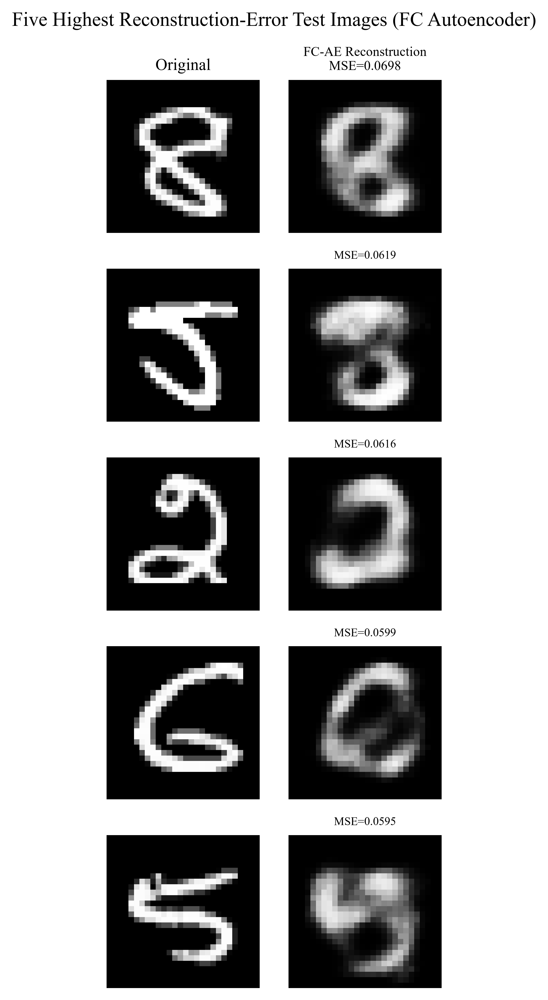

In [34]:
# Section 24 - the five worst test images for the basic FC autoencoder
worst_idx = np.argsort(per_image_mse_fc)[-5:][::-1]

display_image_columns(
    [("Original", x_test[worst_idx]), ("FC-AE Reconstruction", fc_recon[worst_idx])],
    n=5,
    title="Five Highest Reconstruction-Error Test Images (FC Autoencoder)",
    filename="high_error_images",
    error_list=per_image_mse_fc[worst_idx]
)

# Inference: the worst images are usually unusual handwriting - strongly
# slanted, very thin/thick strokes, or digits written so they resemble other
# classes. They are rare in training, so the compressed latent code represents
# them poorly. Note the reconstruction error does not always match perceived
# quality: a blurry-but-correct digit can have moderate MSE while an
# 'unusual-looking but confident' reconstruction can have low MSE.


In [35]:
consolidated = pd.DataFrame({
    "Model": ["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE", "VAE (dz=2)"],
    "MSE": [fc_mse, cae_mse, dae_mse, vae_mse],
    "MAE": [fc_mae, cae_mae, dae_mae, vae_mae],
    "SSIM": [fc_ssim, cae_ssim, dae_ssim, vae_ssim],
    "Parameters": [fc_ae.count_params(), cae.count_params(), dae.count_params(),
                   vae.encoder.count_params() + vae.decoder.count_params()],
    "Time (s)": [fc_time, cae_time, dae_time, vae_time],
})
print(consolidated.to_string(index=False))

# Note: the DAE row is measured on sigma=0.2 noisy inputs, and the VAE is
# trained with a different objective (BCE + KL), so its pixel metrics are not
# directly comparable to the three reconstruction-only models.


            Model      MSE      MAE     SSIM  Parameters  Time (s)
   FC Autoencoder 0.021484 0.057818 0.754313      211040  6.767651
Conv. Autoencoder 0.002682 0.015649 0.972809       74497 56.448077
    Denoising CAE 0.004634 0.021571 0.946698       74497 55.010177
       VAE (dz=2) 0.044264 0.102821 0.502727      134165 44.532098


[FC-AE (dz=2)] final train loss=0.2304  val loss=0.2314  time=6.8s
[FC-AE (dz=8)] final train loss=0.1456  val loss=0.1484  time=6.0s
[FC-AE (dz=16)] final train loss=0.1245  val loss=0.1271  time=6.1s
[FC-AE (dz=32)] final train loss=0.1219  val loss=0.1255  time=6.3s
 Latent Dimension      MSE     SSIM  Parameters  Time (s)
                2 0.057084 0.336164      210130  6.768446
                8 0.027916 0.687151      210520  6.033256
               16 0.020623 0.768160      211040  6.063629
               32 0.019906 0.772646      212080  6.326097
saved latent_dim_vs_mse.eps


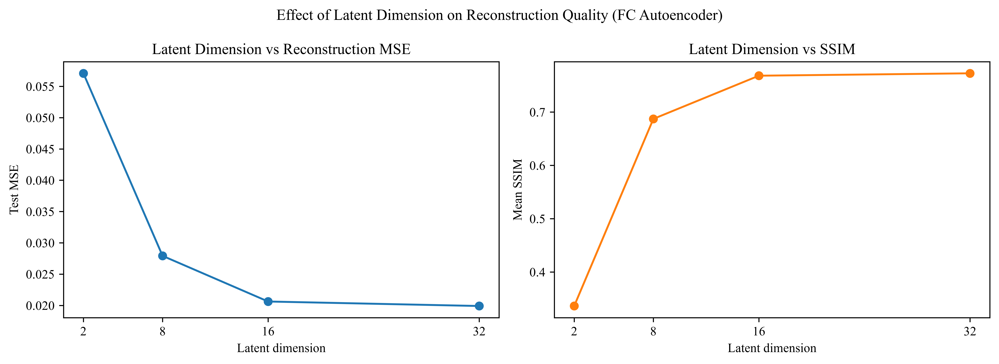

In [36]:
latent_dims = [2, 8, 16, 32]
ld_rows = []
for dz in latent_dims:
    ae = build_fc_ae(dz)
    _, t = fit_and_time(ae, x_tr_flat, x_tr_flat, x_val_flat, x_val_flat,
                        f"FC-AE (dz={dz})")
    rec = ae.predict(x_test_flat, verbose=0).reshape(-1, 28, 28)
    m, _, s = reconstruction_metrics(x_test, rec)
    ld_rows.append({"Latent Dimension": dz, "MSE": m, "SSIM": s,
                    "Parameters": ae.count_params(), "Time (s)": t})

ld_table = pd.DataFrame(ld_rows)
print(ld_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ld_table["Latent Dimension"], ld_table["MSE"], marker='o')
axes[0].set_xticks(latent_dims)
axes[0].set_xlabel("Latent dimension"); axes[0].set_ylabel("Test MSE")
axes[0].set_title("Latent Dimension vs Reconstruction MSE")
axes[1].plot(ld_table["Latent Dimension"], ld_table["SSIM"], marker='o', color='tab:orange')
axes[1].set_xticks(latent_dims)
axes[1].set_xlabel("Latent dimension"); axes[1].set_ylabel("Mean SSIM")
axes[1].set_title("Latent Dimension vs SSIM")
plt.suptitle("Effect of Latent Dimension on Reconstruction Quality (FC Autoencoder)")
plt.tight_layout()
save_plot("latent_dim_vs_mse")
plt.show()

# Inference: error drops steeply from dz=2 to dz=8/16 and then nearly plateaus
# by dz=32. dz=2 forces such heavy compression that digits come out blurred;
# beyond ~16 the extra dimensions buy little while parameters keep growing.
# This is the compression <-> reconstruction quality trade-off: the latent
# dimension sets how much information survives the bottleneck.


In [46]:
#Additional Exercise
# 1. Convolutional AE with latent dims 4, 8, 16, 32 (dense bottleneck)
cae_ld_rows = []
for dz in [4, 8, 16, 32]:
    ae, _, _ = build_conv_ae(latent_dim=dz)
    fit_and_time(ae, x_tr_img, x_tr_img, x_val_img, x_val_img,
                 f"Conv-AE (dense bottleneck dz={dz})")
    rec = ae.predict(x_test_img, verbose=0)
    m, _, s = reconstruction_metrics(x_test, rec)
    cae_ld_rows.append({"Latent Dimension": dz, "MSE": m, "SSIM": s,
                        "Parameters": ae.count_params()})
print(pd.DataFrame(cae_ld_rows).to_string(index=False))

# Inference: the dense bottleneck throttles how much spatial detail reaches
# the decoder - quality improves a lot from 4 to 16 but the natural 3136-dim
# feature-map latent (main CAE above) still reconstructs best. Same
# compression trade-off as the FC study, but with spatial structure preserved
# on both sides of the bottleneck.

[Conv-AE (dense bottleneck dz=4)] final train loss=0.1777  val loss=0.1812  time=55.0s
[Conv-AE (dense bottleneck dz=8)] final train loss=0.1384  val loss=0.1404  time=54.9s
[Conv-AE (dense bottleneck dz=16)] final train loss=0.1114  val loss=0.1150  time=55.3s
[Conv-AE (dense bottleneck dz=32)] final train loss=0.0880  val loss=0.0910  time=56.0s
 Latent Dimension      MSE     SSIM  Parameters
                4 0.039902 0.562895      102725
                8 0.025630 0.722088      127817
               16 0.016878 0.818290      178001
               32 0.008994 0.906766      278369


In [38]:
# 2. Gaussian vs salt-and-pepper using the same denoising architecture
x_tr_sp = add_salt_pepper_noise(x_tr_img, 0.10)
x_val_sp = add_salt_pepper_noise(x_val_img, 0.10)

dae_sp, _, _ = build_conv_ae()
fit_and_time(dae_sp, x_tr_sp, x_tr_img, x_val_sp, x_val_img,
             "Denoising-CAE (salt & pepper trained)")

x_test_gauss = add_gaussian_noise(x_test_img, 0.2)
x_test_sp = add_salt_pepper_noise(x_test_img, 0.10)

sp_rows = []
for name, model in [("Gaussian-trained DAE", dae), ("Salt&pepper-trained DAE", dae_sp)]:
    _, _, ssim_g = reconstruction_metrics(x_test_img, model.predict(x_test_gauss, verbose=0))
    _, _, ssim_p = reconstruction_metrics(x_test_img, model.predict(x_test_sp, verbose=0))
    sp_rows.append({"Model": name, "SSIM on Gaussian (0.2)": ssim_g,
                    "SSIM on Salt&Pepper (0.10)": ssim_p})
print(pd.DataFrame(sp_rows).to_string(index=False))

# Inference: each denoiser performs best on the corruption it was trained on.
# Cross-corruption denoising still works partially (both noises push pixels
# off the clean manifold) but the mismatch costs SSIM.


[Denoising-CAE (salt & pepper trained)] final train loss=0.0767  val loss=0.0774  time=53.9s
                  Model  SSIM on Gaussian (0.2)  SSIM on Salt&Pepper (0.10)
   Gaussian-trained DAE                0.946490                    0.900195
Salt&pepper-trained DAE                0.731361                    0.945029


In [39]:
# 3. Train the denoising AE at two different noise levels and compare SSIM
dae_low, _, _ = build_conv_ae()
fit_and_time(dae_low, add_gaussian_noise(x_tr_img, 0.1), x_tr_img,
             add_gaussian_noise(x_val_img, 0.1), x_val_img,
             "Denoising-CAE (sigma=0.1 trained)")
dae_high, _, _ = build_conv_ae()
fit_and_time(dae_high, add_gaussian_noise(x_tr_img, 0.3), x_tr_img,
             add_gaussian_noise(x_val_img, 0.3), x_val_img,
             "Denoising-CAE (sigma=0.3 trained)")

noise_train_rows = []
for sigma in [0.1, 0.2, 0.3]:
    x_noisy = add_gaussian_noise(x_test_img, sigma)
    row = {"Test sigma": sigma}
    for train_sigma, mdl in [(0.1, dae_low), (0.2, dae), (0.3, dae_high)]:
        _, _, s = reconstruction_metrics(x_test_img, mdl.predict(x_noisy, verbose=0))
        row[f"SSIM (trained at {train_sigma})"] = s
    noise_train_rows.append(row)
print(pd.DataFrame(noise_train_rows).to_string(index=False))

# Inference: the sigma=0.1-trained model is sharpest on light noise but
# degrades fastest at sigma=0.3; the sigma=0.3-trained model is the most
# robust at heavy noise but slightly blurrier on clean-ish inputs because it
# learned to smooth more aggressively.

[Denoising-CAE (sigma=0.1 trained)] final train loss=0.0708  val loss=0.0713  time=56.4s
[Denoising-CAE (sigma=0.3 trained)] final train loss=0.0822  val loss=0.0834  time=52.8s
 Test sigma  SSIM (trained at 0.1)  SSIM (trained at 0.2)  SSIM (trained at 0.3)
        0.1               0.965232               0.960441               0.951027
        0.2               0.901589               0.946659               0.942539
        0.3               0.737100               0.887022               0.920846


[Conv-AE (Conv2DTranspose decoder)] final train loss=0.0670  val loss=0.0674  time=35.8s
            Decoder      MSE      MAE     SSIM  Parameters
UpSampling + Conv2D 0.002682 0.015649 0.972809       74497
    Conv2DTranspose 0.002120 0.013593 0.979607       74497
saved transposed_decoder_comparison.eps


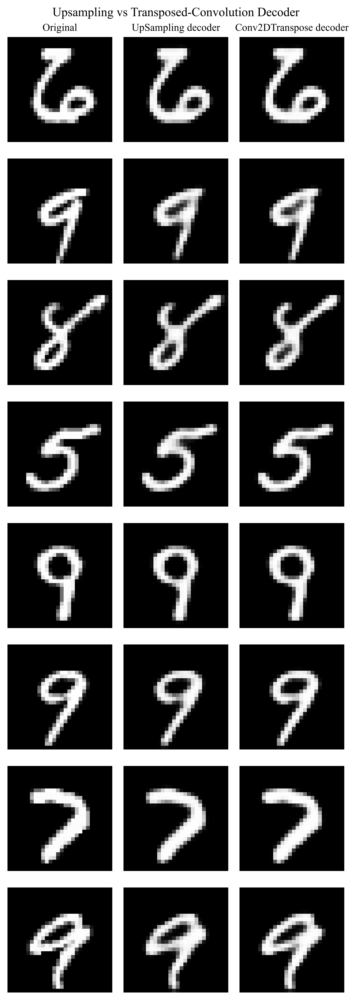

In [40]:
# 4. Replace the upsampling decoder with transposed convolutions
cae_t, _, _ = build_conv_ae(transposed_decoder=True)
fit_and_time(cae_t, x_tr_img, x_tr_img, x_val_img, x_val_img,
             "Conv-AE (Conv2DTranspose decoder)")
cae_t_recon = cae_t.predict(x_test_img, verbose=0)
t_mse, t_mae, t_ssim = reconstruction_metrics(x_test, cae_t_recon)

print(pd.DataFrame({
    "Decoder": ["UpSampling + Conv2D", "Conv2DTranspose"],
    "MSE": [cae_mse, t_mse], "MAE": [cae_mae, t_mae], "SSIM": [cae_ssim, t_ssim],
    "Parameters": [cae.count_params(), cae_t.count_params()],
}).to_string(index=False))

display_image_columns(
    [("Original", x_test), ("UpSampling decoder", cae_recon),
     ("Conv2DTranspose decoder", cae_t_recon)],
    n=8, title="Upsampling vs Transposed-Convolution Decoder",
    filename="transposed_decoder_comparison"
)

# Inference: transposed convolutions learn their own upsampling, which can
# give slightly crisper edges but may introduce faint checkerboard artefacts;
# overall metrics land close to the upsampling decoder.

[VAE (dz=8)] final train loss=148.0593  val loss=151.0821  time=40.5s


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


 VAE  Test MSE  Mean SSIM
dz=2  0.044264   0.502727
dz=8  0.038208   0.596153
saved vae8_latent_space.eps


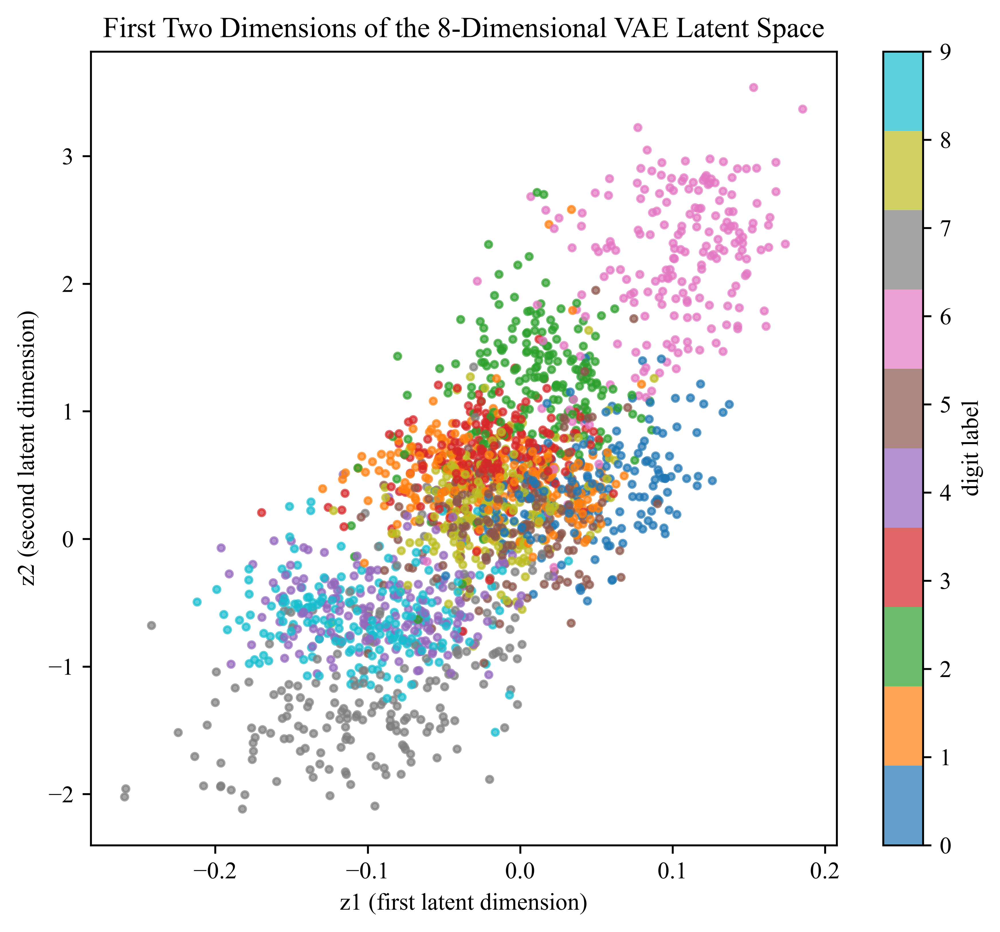

In [41]:
# 5. VAE with latent dimension 2 vs 8
vae8 = build_vae(latent_dim=8)
vae8.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
fit_and_time(vae8, x_tr_img, x_tr_img, x_val_img, x_val_img, "VAE (dz=8)", epochs=30)

z_mu8, _ = vae8.encoder.predict(x_test_img, verbose=0)
vae8_recon = vae8.decoder.predict(z_mu8, verbose=0)
v8_mse, _, v8_ssim = reconstruction_metrics(x_test, vae8_recon)

print(pd.DataFrame({
    "VAE": ["dz=2", "dz=8"],
    "Test MSE": [vae_mse, v8_mse], "Mean SSIM": [vae_ssim, v8_ssim],
}).to_string(index=False))

plt.figure(figsize=(7, 6))
sc = plt.scatter(z_mu8[:, 0], z_mu8[:, 1], c=y_test, cmap='tab10', s=8, alpha=0.7)
plt.colorbar(sc, label="digit label")
plt.xlabel("z1 (first latent dimension)"); plt.ylabel("z2 (second latent dimension)")
plt.title("First Two Dimensions of the 8-Dimensional VAE Latent Space")
save_plot("vae8_latent_space")
plt.show()

# Inference: dz=8 reconstructs clearly better (more latent capacity), but its
# first-two-dimensions projection is less cleanly separated because the
# information is spread across all 8 dimensions - a visualisability vs
# fidelity trade-off.


[VAE (beta=0.5)] final train loss=160.7708  val loss=162.0124  time=41.3s
[VAE (beta=2.0)] final train loss=167.1145  val loss=168.0448  time=40.0s
[VAE (beta=4.0)] final train loss=173.9398  val loss=174.7118  time=40.2s
 Beta (KL weight)  Test MSE  Mean SSIM  KL Loss
              1.0  0.044264   0.502727 5.820126
              0.5  0.046732   0.485180 7.806854
              2.0  0.046485   0.481440 4.981767
              4.0  0.047050   0.464081 3.501314
saved kl_weight_samples.eps


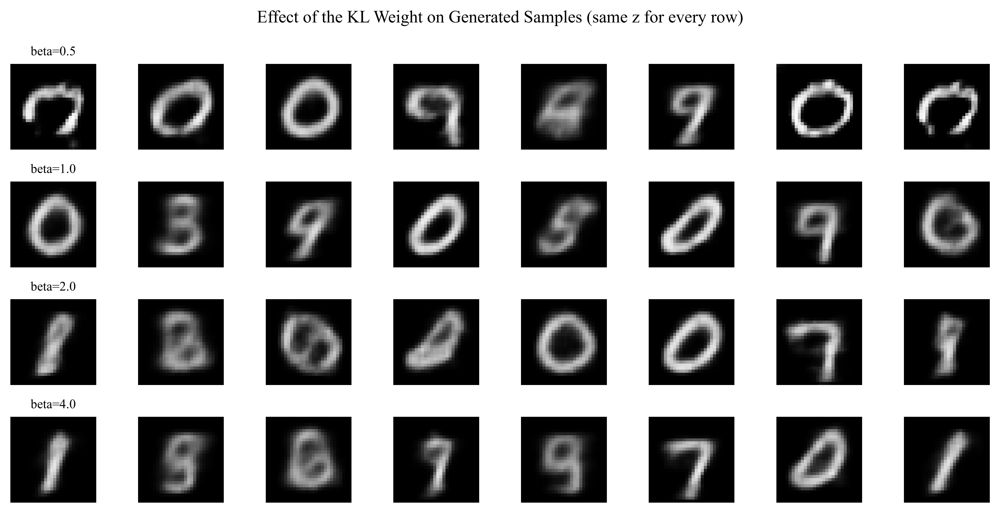

In [42]:
# 6. Effect of increasing the KL-loss contribution (beta = KL weight)
z_fixed = np.random.normal(0.0, 1.0, size=(8, 2))   # same z for every row
beta_models = {1.0: vae}
beta_rows = [{"Beta (KL weight)": 1.0, "Test MSE": vae_mse,
              "Mean SSIM": vae_ssim, "KL Loss": vae_kl_loss}]

for beta in [0.5, 2.0, 4.0]:
    vae_b = build_vae(2, kl_weight=beta)
    vae_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
    fit_and_time(vae_b, x_tr_img, x_tr_img, x_val_img, x_val_img,
                 f"VAE (beta={beta})", epochs=30)
    mu_b, logvar_b = vae_b.encoder.predict(x_test_img, verbose=0)
    recon_b = vae_b.decoder.predict(mu_b, verbose=0)
    b_mse, _, b_ssim = reconstruction_metrics(x_test, recon_b)
    kl_b = float(np.mean(-0.5 * np.sum(1 + logvar_b - mu_b ** 2 - np.exp(logvar_b), axis=1)))
    beta_models[beta] = vae_b
    beta_rows.append({"Beta (KL weight)": beta, "Test MSE": b_mse,
                      "Mean SSIM": b_ssim, "KL Loss": kl_b})

print(pd.DataFrame(beta_rows).to_string(index=False))

plt.figure(figsize=(10, 5))
for r, (beta, mdl) in enumerate(sorted(beta_models.items())):
    imgs = mdl.decoder.predict(z_fixed, verbose=0)
    for c in range(8):
        plt.subplot(len(beta_models), 8, r * 8 + c + 1)
        plt.imshow(imgs[c].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
        if c == 0:
            plt.title(f"beta={beta}", fontsize=9)
plt.suptitle("Effect of the KL Weight on Generated Samples (same z for every row)")
plt.tight_layout()
save_plot("kl_weight_samples")
plt.show()

# Inference: higher beta squeezes the latent harder toward the prior (lower KL)
# but hurts reconstruction and blurs the samples; lower beta gives sharper
# reconstructions but a less regular latent, so random samples can be worse.
# beta=1 is the standard balance.

In [43]:
# 7. Larger grid of VAE samples (100 images) to discuss diversity
z_big = np.random.normal(0.0, 1.0, size=(100, 2))
big_grid = vae.decoder.predict(z_big, verbose=0)
show_image_grid(big_grid, cols=10,
                title="100 VAE-Generated Images (larger sample grid)",
                filename="vae_large_grid")

# Inference: the grid shows a wide variety of digits and writing styles, with
# a few repeated-looking or ambiguous ones - the diversity reflects how broadly
# the learned latent distribution covers the training manifold.


saved vae_large_grid.eps


saved digit_region_interpolation.eps


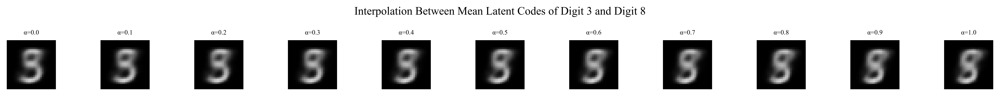

In [44]:
# 8. Interpolation between two digit REGIONS (mean latent codes of two digits)
zA = z_mu_test[y_test == 3].mean(axis=0, keepdims=True)
zB = z_mu_test[y_test == 8].mean(axis=0, keepdims=True)
z_interp_digits = (1 - alphas)[:, None] * zA + alphas[:, None] * zB
digit_interp_imgs = vae.decoder.predict(z_interp_digits, verbose=0)

show_image_grid(digit_interp_imgs, cols=11,
                title="Interpolation Between Mean Latent Codes of Digit 3 and Digit 8",
                filename="digit_region_interpolation",
                titles=[f"α={a:.1f}" for a in alphas])

# Inference: moving between the average codes of two digit classes again
# produces a smooth morph, confirming the smoothness holds at the region
# level, not just between two individual points.

In [45]:
# ## Discussion Questions (to write in report)
#
# 1. An autoencoder is an unsupervised neural network trained to copy its
#    input to its output through a narrow bottleneck, forcing it to learn a
#    compressed representation instead of memorising the data.
# 2. The encoder compresses the input image into the low-dimensional latent
#    code z, keeping only the information needed to describe it.
# 3. The decoder expands the latent code back into an image, reconstructing
#    the original input from the compressed representation.
# 4. A latent representation is the internal code the encoder produces - a
#    compact summary of the essential structure of the input.
# 5. It is smaller than the input so the network cannot pass the image through
#    unchanged; the bottleneck forces it to discard redundancy and keep only
#    the important factors of variation.
# 6. If the latent dimension is too small the bottleneck destroys information,
#    so reconstructions become blurred and fine details (thin strokes, small
#    loops) are lost.
# 7. Increasing the latent dimension lets more information through so
#    reconstruction improves, but gains saturate, parameters grow, and the
#    model risks becoming a near-identity function that learns nothing useful.
# 8. Convolutional layers process every local patch with the same shared
#    filters and preserve the spatial arrangement of pixels, so strokes and
#    their positions are represented naturally; dense layers must relearn
#    those spatial relations separately for each pixel position.
# 9. An autoencoder is trained to reconstruct clean inputs from clean inputs;
#    a denoising autoencoder is trained to reconstruct the clean image from a
#    corrupted version of it, so it learns a mapping that removes noise.
# 10. Using the clean image as the target is what teaches the network to undo
#     the corruption - if the noisy image were the target, the best strategy
#     would be to copy the noise.
# 11. As the noise level increases, more of the true signal is destroyed, the
#     input moves further from the clean-data manifold, and the denoiser can
#     recover less detail, so MSE rises and SSIM falls.
# 12. MSE and MAE give simple pixel-level average error magnitudes (MSE
#     penalises large errors more), while SSIM measures structural similarity
#     and agrees better with human perception, so together they give a fuller
#     picture than any single metric.
# 13. A variational autoencoder is an autoencoder whose encoder outputs the
#     parameters of a probability distribution over latent codes instead of a
#     single code, trained with reconstruction loss plus KL divergence.
# 14. A conventional AE maps an input to one deterministic point and its
#     latent space is unstructured; a VAE maps each input to a distribution
#     and regularises the aggregate latent space toward N(0, I), making it
#     generative and its latent space smooth.
# 15. Learning a distribution means each training image influences a whole
#     region of latent space, and the KL term keeps those regions overlapping
#     and centred - so points near the origin decode meaningfully and new
#     images can be produced by sampling.
# 16. The reparameterization trick writes the sampled latent as
#     z = mu + sigma*eps with eps ~ N(0, I), moving the randomness into an
#     external variable so gradients can flow through mu and sigma during
#     backpropagation.
# 17. eps comes from a standard normal so that z is distributed as
#     N(mu, sigma^2) - the encoder's sigma simply rescales standard noise, and
#     the standard normal matches the shape of the prior.
# 18. The KL divergence penalises how far each q(z|x) is from the prior
#     N(0, I); it organises and regularises the latent space and creates the
#     trade-off between reconstruction sharpness and generative ability.
# 19. The prior is a standard multivariate normal N(0, I).
# 20. With two latent dimensions every code is a point on a plane, so the
#     whole latent structure (clusters, overlaps, gaps) can be drawn directly
#     as a 2D scatter plot without any projection.
# 21. Interpolation demonstrates continuity: if decoding points along the line
#     between two codes produces a gradual, plausible morph, the space has no
#     gaps along that path.
# 22. Because the KL term makes the aggregate of all q(z|x) look like N(0, I),
#     a z sampled from N(0, I) lands in a region the decoder was trained on,
#     so decoding it yields a plausible new image.
# 23. Some samples are unclear when z falls between clusters or in poorly
#     covered regions, or because a 2D latent is too small to encode all the
#     fine detail of handwriting - the loss also explicitly trades
#     reconstruction quality for latent regularity.
# 24. Reconstruction encodes an existing image and decodes it back
#     (input-dependent); generation samples a latent from the prior and
#     decodes it without any input image (input-independent).
# 25. Test images must stay unseen so the reported metrics measure how well
#     the learned representation generalises to new data rather than how well
#     the model memorised images it was optimised on.